In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from collections import Counter

ALGORITHM 1: DESCISION TREE

In [23]:
df=pd.read_csv(r"C:\Users\Samaira Singh\Downloads\bootcamp\ml\star_classification.csv")
print(df.head())
#finding unique falues in the string column
print(df["class"].unique())

#mapping non numerical values (encoding)
d={"GALAXY":0,"QSO":1,"STAR":2}
df["class"]=df["class"].map(d)
print(df.head())

         obj_ID       alpha      delta         u         g         r  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.27530  20.39501   
1  1.237665e+18  144.826101  31.274185  24.77759  22.83188  22.58444   
2  1.237661e+18  142.188790  35.582444  25.26307  22.66389  20.60976   
3  1.237663e+18  338.741038  -0.402828  22.13682  23.77656  21.61162   
4  1.237680e+18  345.282593  21.183866  19.43718  17.58028  16.49747   

          i         z  run_ID  rerun_ID  cam_col  field_ID   spec_obj_ID  \
0  19.16573  18.79371    3606       301        2        79  6.543777e+18   
1  21.16812  21.61427    4518       301        5       119  1.176014e+19   
2  19.34857  18.94827    3606       301        2       120  5.152200e+18   
3  20.50454  19.25010    4192       301        3       214  1.030107e+19   
4  15.97711  15.54461    8102       301        3       137  6.891865e+18   

    class  redshift  plate    MJD  fiber_ID  
0  GALAXY  0.634794   5812  56354       171  
1  GALAXY  0.77913

In [13]:
# separate the feature columns from the target column.
features=['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
X=df[features]
Y=df["class"]
print(X)
print(Y)

            alpha      delta         u         g         r         i  \
0      135.689107  32.494632  23.87882  22.27530  20.39501  19.16573   
1      144.826101  31.274185  24.77759  22.83188  22.58444  21.16812   
2      142.188790  35.582444  25.26307  22.66389  20.60976  19.34857   
3      338.741038  -0.402828  22.13682  23.77656  21.61162  20.50454   
4      345.282593  21.183866  19.43718  17.58028  16.49747  15.97711   
...           ...        ...       ...       ...       ...       ...   
99995   39.620709  -2.594074  22.16759  22.97586  21.90404  21.30548   
99996   29.493819  19.798874  22.69118  22.38628  20.45003  19.75759   
99997  224.587407  15.700707  21.16916  19.26997  18.20428  17.69034   
99998  212.268621  46.660365  25.35039  21.63757  19.91386  19.07254   
99999  196.896053  49.464643  22.62171  21.79745  20.60115  20.00959   

              z  redshift  
0      18.79371  0.634794  
1      21.61427  0.779136  
2      18.94827  0.644195  
3      19.25010  0.9323

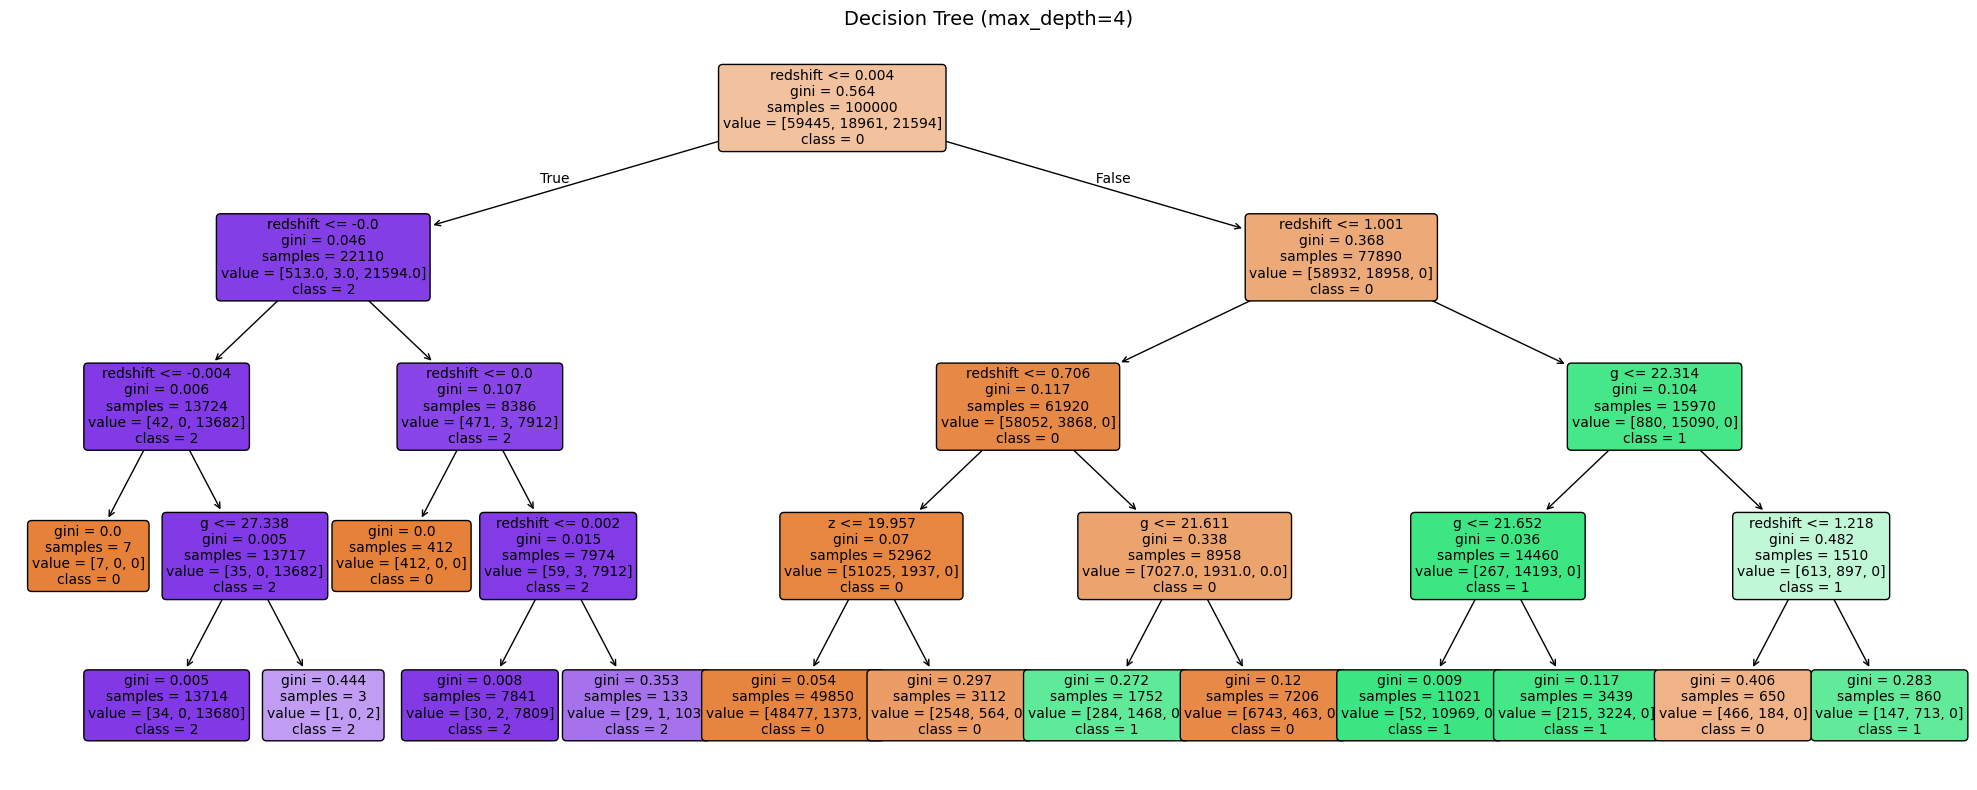

In [18]:
#create the actual decision tree, fit it with our details
dtree = DecisionTreeClassifier(max_depth=4, random_state=42)  # limit depth otherwise goes on till impurity is 0
dtree = dtree.fit(X, Y)

plt.figure(figsize=(20, 8))
tree.plot_tree(
    dtree,
    feature_names=features,
    class_names=dtree.classes_.astype(str),
    filled=True,          # colour nodes by majority class
    rounded=True,         # rounded boxes
    fontsize=10
)
plt.title("Decision Tree (max_depth=4)", fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)
def confusion_matrix_manual(y_true, y_pred, classes):
    n = len(classes)
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[classes.index(t)][classes.index(p)] += 1
    return cm
y_pred=dtree.predict(X)
acc=accuracy(Y,y_pred)
print(acc)

classes=[0,1,2]
cm=confusion_matrix_manual(Y,y_pred,classes)
print(cm)
print("\n the accuracy of the model is 96.621% ")
print("confusion matrix shows that :")
print("STAR class has zero misclassifications-100% recall ")
print("GALAXY class has 58,653 correct classifications and 698+94 missclassification")
print("QSO class has 16374 correct and 2584+3 wrong")

0.96621
[[58653   698    94]
 [ 2584 16374     3]
 [    0     0 21594]]

 the accuracy of the model is 96.621% 
confusion matrix shows that :
STAR class has zero misclassifications-100% recall 
GALAXY class has 58,653 correct classifications and 698+94 missclassification
QSO class has 16374 correct and 2584+3 wrong


ALGORITHM 2: K-MEANS CLUSTERING 

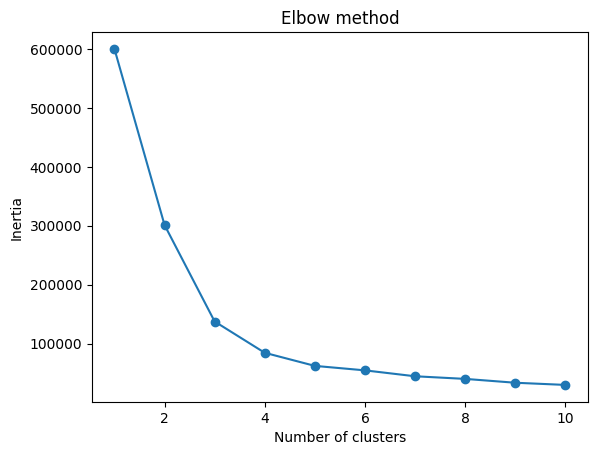

In [52]:
from sklearn.cluster import KMeans
#taking features as data points 
features = ['redshift', 'u', 'g', 'r', 'i', 'z']
x=df["redshift"]
y=df["g"]
x_norm=(x-np.mean(x))/np.std(x)
y_norm=(y-np.mean(y))/np.std(y)
x_clip = np.clip(x_norm, -3, 3)
y_clip = np.clip(y_norm, -3, 3)

data = df[features].values

# Normalise each column 
data_norm = (data - np.mean(data, axis=0)) / np.std(data, axis=0)

inertias = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(data_norm)
    inertias.append(kmeans.inertia_)
    
#utilizing the elbow method to visualize the intertia for different values of K:

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

The elbow curve shows sharp inertia reduction up to k=3, beyond which the rate of decrease becomes minimal. This suggests k=3 as the optimal number of clusters, which aligns perfectly with the 3 known stellar classes in the dataset — STAR, GALAXY, and QSO.

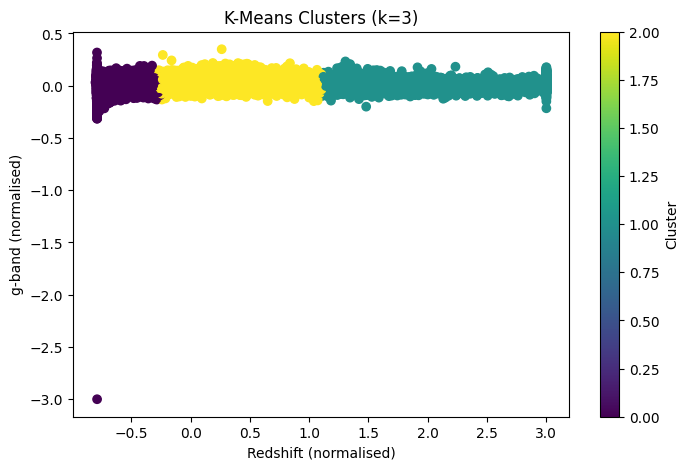

In [55]:
#each data point is randomly assigned to one of the K clusters. Then, we compute the centroid (functionally the center) of each cluster,
#and reassign each data point to the cluster with the closest centroid. 
#We repeat this process until the cluster assignments for each data point are no longer changing

data_norm = list(zip(x_clip, y_clip))

# Refit KMeans using K=3
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(data_norm)

plt.figure(figsize=(8, 5))
plt.scatter(x_clip, y_clip, c=kmeans.labels_)
plt.xlabel('Redshift (normalised)')
plt.ylabel('g-band (normalised)')
plt.title('K-Means Clusters (k=3)')
plt.colorbar(label='Cluster')
plt.show()

In [73]:
feat=df[["redshift","g"]]
y_pred=kmeans.predict(feat)
acc=np.mean(y_pred==Y)
print(f"Kmeans Accuracy: {acc:.4f}")
cm = confusion_matrix_manual(Y, y_pred, classes)
print(cm)

C:\Users\Samaira Singh\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(


Kmeans Accuracy: 0.3221
[[    0    81 59364]
 [    0 10614  8347]
 [    1     0 21593]]


ALGORITHM 3: KNN

In [69]:
#KNN is a simple, supervised machine learning (ML) algorithm.
#It is based on the idea that the observations closest to a given data point are the most "similar" observations in a data set
#we can therefore classify unforeseen points based on the values of the closest existing points.
#By choosing K, the user can select the number of nearby observations to use in the algorithm.
from sklearn.neighbors import KNeighborsClassifier

data = list(zip(x_norm, y_norm))
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(data, df["class"])
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, Y)

y_pred = knn.predict(X)

In [65]:
acc = np.mean(y_pred == Y)
print(f"KNN Accuracy: {acc:.4f}")
cm = confusion_matrix_manual(Y, y_pred, classes)
print(cm)

KNN Accuracy: 0.8834
[[57347   719  1379]
 [ 2086 16319   556]
 [ 6017   906 14671]]


ANALYSIS

DECISION TREE
1.Accuracy:  96.62%
2.Risk of overfitting; max_depth=4 used 

K-MEANS
1.Accuracy:  32.21% 
2.Unsupervised

KNN 
1.Accuracy:  88.34%
2.requies normalisation

descision performs the best